In [1]:
import pandas as pd
import re

In [2]:
train_data = pd.read_csv("/kaggle/input/competitions/playground-series-s6e5/train.csv")
test_df = pd.read_csv(
    "/kaggle/input/competitions/playground-series-s6e5/test.csv")
#train_data = train_data.drop('id', axis = 1)

In [3]:
train_data.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', col).lower() for col in train_data.columns]
test_df.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', col).lower() for col in test_df.columns]

In [4]:
test_df.isnull().sum()

id                        0
driver                    0
compound                  0
race                      0
year                      0
pitstop                   0
lapnumber                 0
stint                     0
tyrelife                  0
position                  0
laptime_s_                0
laptime_delta             0
cumulative_degradation    0
raceprogress              0
position_change           0
dtype: int64

In [5]:
def feature_engineering(train_data):
    train_data["pace_per_tyre"] = (
    train_data["laptime_s_"] / (train_data["tyrelife"] + 1))

    train_data["deg_per_lap"] = (
    train_data["cumulative_degradation"] /
    (train_data["lapnumber"] + 1)
)

    train_data["race_tyre_interaction"] = (
    train_data["raceprogress"] *
    train_data["tyrelife"]
)
    train_data["position_pressure"] = (
    train_data["position"] *
    train_data["laptime_delta"]
)
    train_data["stint_efficiency"] = (
    train_data["stint"] /
    (train_data["tyrelife"] + 1)
)
    train_data["tyre_stress"] = (
    train_data["tyrelife"] *
    train_data["cumulative_degradation"]
)
    return train_data

In [6]:
train_data=feature_engineering(train_data)
test_df = feature_engineering(test_df)

In [7]:
cat_col = train_data.select_dtypes(include='object').columns
cat_col

Index(['driver', 'compound', 'race'], dtype='object')

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_col:
    X_full=pd.concat([train_data[col],test_df[col]],axis=0).astype(str)
    
    le.fit(X_full)

    train_data[col]=le.transform(train_data[col])
    test_df[col]=le.transform(test_df[col])

    


    

In [9]:
train_data=train_data.drop('id',axis=1)
test_df=test_df.drop('id',axis=1)

train_data=train_data.rename(columns={"pitstop":"PitStop"})
test_df=test_df.rename(columns={"pitstop":"PitStop"})

<Axes: >

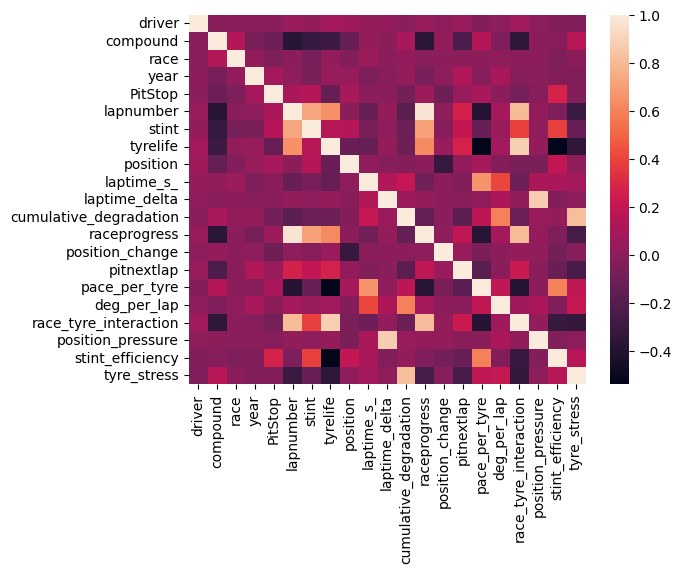

In [10]:
import seaborn as sns

corr = train_data.corr()
sns.heatmap(corr)

In [11]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split

X = train_data.drop("PitStop", axis=1)
y = train_data["PitStop"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [12]:

model = LGBMClassifier()

model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 47893, number of negative: 303419
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.039744 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3002
[LightGBM] [Info] Number of data points in the train set: 351312, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.136326 -> initscore=-1.846145
[LightGBM] [Info] Start training from score -1.846145


LGBMClassifier()

In [13]:
importance = model.feature_importances_

for feature, score in zip(X.columns, importance):
    print(feature, score)

driver 40
compound 82
race 447
year 189
lapnumber 242
stint 206
tyrelife 193
position 109
laptime_s_ 284
laptime_delta 333
cumulative_degradation 220
raceprogress 101
position_change 148
pitnextlap 52
pace_per_tyre 89
deg_per_lap 52
race_tyre_interaction 19
position_pressure 51
stint_efficiency 90
tyre_stress 53


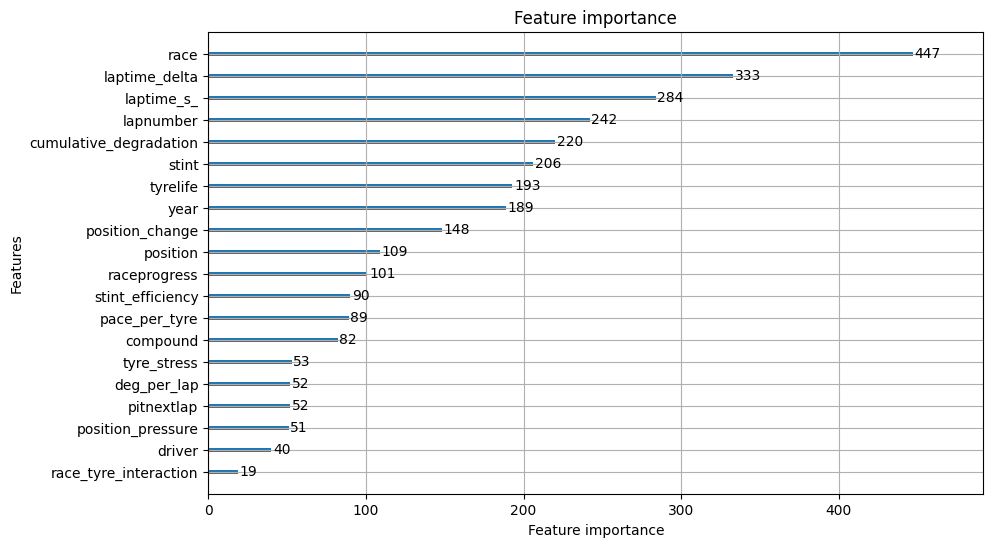

In [14]:
import lightgbm as lgb
import matplotlib.pyplot as plt

lgb.plot_importance(model, figsize=(10,6))

plt.show()

In [15]:
train_data.columns.tolist()

['driver',
 'compound',
 'race',
 'year',
 'PitStop',
 'lapnumber',
 'stint',
 'tyrelife',
 'position',
 'laptime_s_',
 'laptime_delta',
 'cumulative_degradation',
 'raceprogress',
 'position_change',
 'pitnextlap',
 'pace_per_tyre',
 'deg_per_lap',
 'race_tyre_interaction',
 'position_pressure',
 'stint_efficiency',
 'tyre_stress']

In [16]:
drop_cols = [
    "race_tyre_interaction",
    "driver",
    "pitnextlap",
    "position_pressure",
    "deg_per_lap",
    "tyre_stress"
]

train_data = train_data.drop(
    columns=[c for c in drop_cols if c in train_data.columns]
)

test_df = test_df.drop(
    columns=[c for c in drop_cols if c in test_df.columns]
)

In [17]:
print(train_data["PitStop"].value_counts(normalize = True))

PitStop
0    0.863882
1    0.136118
Name: proportion, dtype: float64


In [18]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import numpy as np

X = train_data.drop("PitStop", axis=1)
y = train_data["PitStop"]

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = []

for train_idx, val_idx in skf.split(X, y):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = LGBMClassifier(
      n_estimators=3000,
        learning_rate=0.01,
        num_leaves=48,              
        min_child_samples=80,       
        subsample=0.7,
        colsample_bytree=0.7,
        class_weight='balanced',
        reg_alpha=0.5,
        reg_lambda=0.5,
        max_bin=255,
        device='gpu',
        random_state=42
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_val)

    score = f1_score(y_val, preds)

    scores.append(score)

print("Mean F1:", np.mean(scores))

[LightGBM] [Info] Number of positive: 47820, number of negative: 303492
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 1740
[LightGBM] [Info] Number of data points in the train set: 351312, number of used features: 14
[LightGBM] [Info] Using GPU Device: Tesla P100-PCIE-16GB, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 14 dense feature groups (5.36 MB) transferred to GPU in 0.008992 secs. 0 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Number of positive: 47820, number of negative: 303492
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 1744
[LightGBM] [Info] Number of data points in the train set: 351312, number of used features: 14
[LightGBM] [Info] Using GPU Device: Tesla P100-PCIE-16GB, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 14 dense feature groups (5.36 MB) transferred to GPU in 0.005788 secs. 0 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> 

In [19]:
X = train_data.drop("PitStop", axis=1)
y = train_data["PitStop"]

model.fit(X, y)

[LightGBM] [Info] Number of positive: 59775, number of negative: 379365
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 1684
[LightGBM] [Info] Number of data points in the train set: 439140, number of used features: 14
[LightGBM] [Info] Using GPU Device: Tesla P100-PCIE-16GB, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 14 dense feature groups (6.70 MB) transferred to GPU in 0.008205 secs. 0 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


LGBMClassifier(class_weight='balanced', colsample_bytree=0.7, device='gpu',
               learning_rate=0.01, max_bin=255, min_child_samples=80,
               n_estimators=3000, num_leaves=48, random_state=42, reg_alpha=0.5,
               reg_lambda=0.5, subsample=0.7)

In [20]:
test_df.columns

Index(['compound', 'race', 'year', 'PitStop', 'lapnumber', 'stint', 'tyrelife',
       'position', 'laptime_s_', 'laptime_delta', 'cumulative_degradation',
       'raceprogress', 'position_change', 'pace_per_tyre', 'stint_efficiency'],
      dtype='object')

In [21]:
test_df = test_df[X.columns]
probs = model.predict_proba(test_df)[:,1]

preds = (probs > 0.35).astype(int)

In [22]:
sample_submission = pd.read_csv(
    "/kaggle/input/competitions/playground-series-s6e5/sample_submission.csv"
)


In [23]:
submission = pd.DataFrame({
    "id": sample_submission["id"],
    "PitStop": preds
})
submission.to_csv("submission.csv", index=False)
print(submission.head())

       id  PitStop
0  439140        0
1  439141        0
2  439142        0
3  439143        1
4  439144        1
